# Small Round Blue Cell Tumors

The small round blue cell tumors (SRBCTs) are 4 different childhood tumors named so because of their similar appearance on routine histology, which makes correct clinical diagnosis extremely challenging. They include Ewing's family of tumors (EWS), neuroblastoma (NB), non-Hodgkin lymphoma (in our case Burkitt's lymphoma, BL) and rhabdomyosarcoma (RMS). This classification model aims to distinguish between these four tumors based on gene expression values.

In [ ]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.datasets import fetch_openml
 
from config.config import N_QUBITS, N_LAYERS, N_POINTS, N_TRIALS, N_EPOCH, N_POPSIZE, N_PM, SEED
from config.experiments import ExperimentConfig
 
from src.data.preprocessing import preprocess
import src.data.saving as saving
from src.data.saving import svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
import src.utils.visuals as visuals
from src.utils.visuals import plot_accuracy, plot_g_best, plot_kernel_heatmaps, graph_kernels, draw_kernel_circuit

from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.utils.visuals import graph_subset

In [13]:
# ── 1. Data ────────────────────────────────────────────────────────────────────

dataset = fetch_openml("SRBCT", version=1, as_frame=True, parser="auto")
X = dataset.data.astype(float)
y = dataset.target   # numeric labels: 1, 2, 3, 4  (class identity unknown from OpenML)

X_train, X_test, y_train, y_test = preprocess(X, y, N_QUBITS)

print(f"Dataset  : {np.unique(dataset.target)}")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/SRBCT dataset'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : [1 2 3 4]
Train    : (58, 4)  |  Test: (25, 4)


In [ ]:
# ── 2. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
 
    # ── OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna_random',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_global',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_stratified',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_per_class': N_POINTS // 4},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_full',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': 58, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),

    # ── MEALPY ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'mealpy_random',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_global',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_stratified',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_per_class': N_POINTS // 4},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_full',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': 58, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

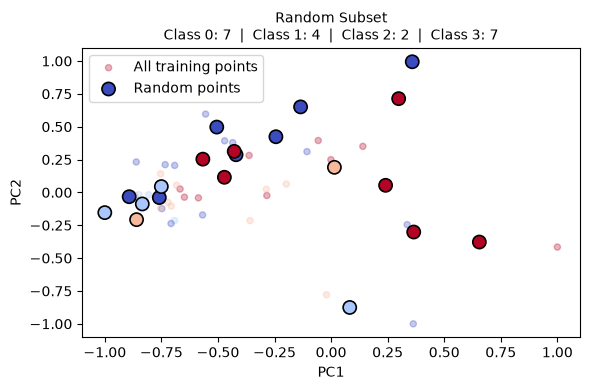

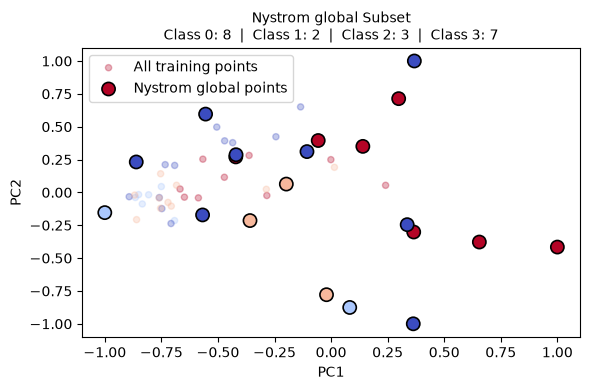

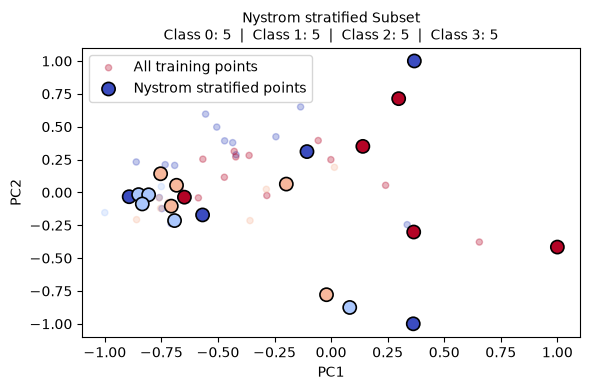

In [17]:
# Dataset structure
_, X_random, y_random = subset_random(X_train, y_train, N_POINTS, SEED)
graph_subset('Random', X_train, X_random, y_train, y_random)

_, X_global, y_global = subset_nystrom_global(X_train, y_train, N_QUBITS, N_POINTS)
graph_subset('Nystrom global', X_train, X_global, y_train, y_global)

_, X_stratified, y_stratified = subset_nystrom_stratified(X_train, y_train, N_QUBITS, N_POINTS // 4)
graph_subset('Nystrom stratified', X_train, X_stratified, y_train, y_stratified)

In [24]:
# ── 3. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}
 
# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}
 
# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")
 
    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.name).get('g_best', float('nan'))
 
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
 
    results = get_svm_results(config, K_train, y_sub, K_test, y_test, cv=2)
 
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-06-30 10:44:51,783] A new study created in memory with name: no-name-0c5b7349-3e09-4c7f-80bd-e35387205b00



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_random  [optuna + random]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_random'
Loading cached SVM results for 'optuna_random'

────────────────────────────────────────────────────────────
 optuna_nystrom_global  [optuna + nystrom_global]
────────────────────────────────────────────────────────────


[I 2026-06-30 10:44:53,119] Trial 0 finished with value: 3.547675053870057 and parameters: {'gate_0': 'I', 'angle_0': 3.1622853332497067, 'gate_1': 'RZ', 'angle_1': 5.636679002188123, 'gate_2': 'RZ', 'angle_2': 4.699631043135449, 'gate_3': 'RZ', 'angle_3': 1.3778179312825802, 'gate_4': 'CNOT', 'angle_4': 2.814085289498672, 'gate_5': 'RZ', 'angle_5': 0.8680216596318117, 'gate_6': 'RX', 'angle_6': 1.3522665661111142, 'gate_7': 'RZ', 'angle_7': 0.0174616841170539, 'gate_8': 'RX', 'angle_8': 5.249933610193376, 'gate_9': 'RX', 'angle_9': 2.720789004063489, 'gate_10': 'I', 'angle_10': 0.3402491221174649, 'gate_11': 'CNOT', 'angle_11': 3.3898320151811157, 'gate_12': 'CNOT', 'angle_12': 3.408223282768507, 'gate_13': 'RY', 'angle_13': 4.15559764599889, 'gate_14': 'RY', 'angle_14': 2.6258108877936817, 'gate_15': 'RY', 'angle_15': 1.1702231933457292}. Best is trial 0 with value: 3.547675053870057.
[I 2026-06-30 10:44:54,395] Trial 1 finished with value: 4.095354251805916 and parameters: {'gate_0'

Saved candidate  → Results/SRBCT dataset/optuna_nystrom_global/candidate.pkl
Computing cross-kernel (test × subset)…


[I 2026-06-30 10:47:23,877] A new study created in memory with name: no-name-7b493cda-9ac5-4a74-9c08-124100559e62


Saved SVM        → Results/SRBCT dataset/optuna_nystrom_global/svm.pkl

REPORT: optuna_nystrom_global | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.1250
Test accuracy     : 0.3200
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         5
           3       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.08      0.25      0.12        25
weighted avg       0.10      0.32      0.16        25


────────────────────────────────────────────────────────────
 optuna_nystrom_stratified  [optuna + nystrom_stratified]
────────────────────────────────────────────────────────────


[I 2026-06-30 10:47:30,066] Trial 0 finished with value: 5.954680098622893 and parameters: {'gate_0': 'RZ', 'angle_0': 5.310617737918435, 'gate_1': 'H', 'angle_1': 2.774663794018275, 'gate_2': 'RY', 'angle_2': 3.1744859806847607, 'gate_3': 'RX', 'angle_3': 2.334207009338601, 'gate_4': 'RX', 'angle_4': 4.88835695660039, 'gate_5': 'RZ', 'angle_5': 2.991786357852539, 'gate_6': 'I', 'angle_6': 0.8296527997777989, 'gate_7': 'H', 'angle_7': 0.8392578311862554, 'gate_8': 'RZ', 'angle_8': 1.1208854829863972, 'gate_9': 'I', 'angle_9': 5.8102306422966965, 'gate_10': 'CNOT', 'angle_10': 5.062307145691293, 'gate_11': 'RY', 'angle_11': 1.6324622324040876, 'gate_12': 'H', 'angle_12': 3.0915605729762596, 'gate_13': 'H', 'angle_13': 5.484626190930507, 'gate_14': 'RX', 'angle_14': 1.450393833587637, 'gate_15': 'CNOT', 'angle_15': 1.933867678930443}. Best is trial 0 with value: 5.954680098622893.
[I 2026-06-30 10:47:36,727] Trial 1 finished with value: 18.109298338490895 and parameters: {'gate_0': 'CNOT

Saved candidate  → Results/SRBCT dataset/optuna_nystrom_stratified/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/SRBCT dataset/optuna_nystrom_stratified/svm.pkl

REPORT: optuna_nystrom_stratified | 100 trials
Best C            : 10
Best CV accuracy  : 0.4250
Test accuracy     : 0.6000
              precision    recall  f1-score   support

           0       0.62      0.56      0.59         9
           1       0.50      0.33      0.40         3
           2       0.67      0.80      0.73         5
           3       0.56      0.62      0.59         8

    accuracy                           0.60        25
   macro avg       0.59      0.58      0.58        25
weighted avg       0.60      0.60      0.59        25



In [26]:
# ── 4. Summary table ───────────────────────────────────────────────────────────
 
def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 75}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 75}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 75}\n")
 
print_summary(summary)


═══════════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
───────────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.7600    0.7458         —     10
  optuna_random                       0.3200    0.4896     14.75    100
  optuna_nystrom_global               0.3200    0.1250      5.60    0.1
  optuna_nystrom_stratified           0.6000    0.4250     73.61     10
═══════════════════════════════════════════════════════════════════════════



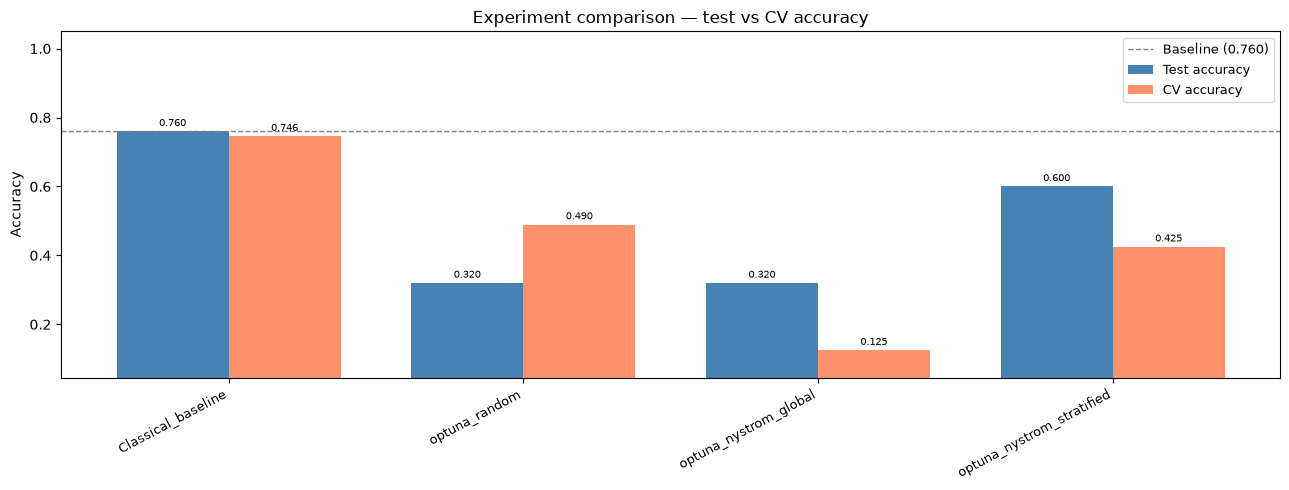

Saved → Results/accuracy_comparison.png


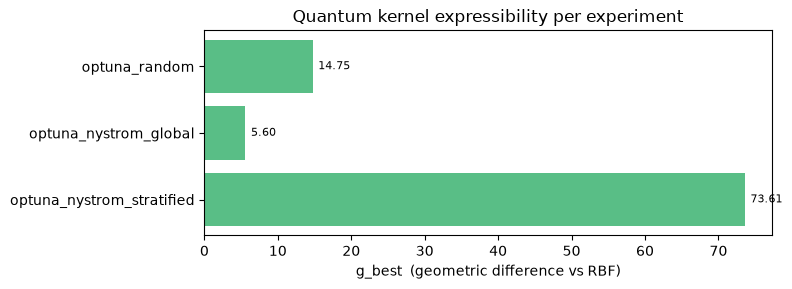

Saved → Results/g_best_comparison.png


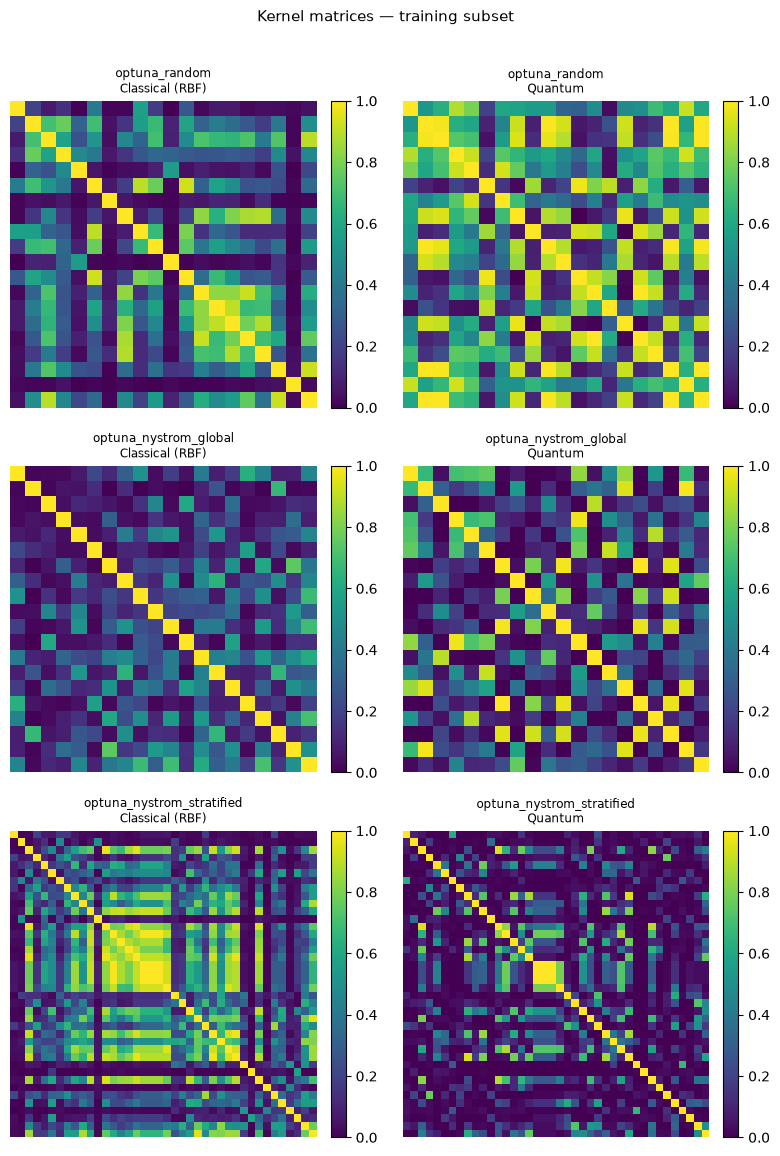

Saved → Results/kernel_heatmaps.png


In [28]:
# ── 5. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary)
plot_g_best(summary)
plot_kernel_heatmaps(summary, max_show=90)